# Proyecto ML — Predicción de Terremotos Significativos

---

## 1. Business Case & Definición del Problema

### 1.1 Contexto del problema

Los terremotos son uno de los fenómenos naturales más destructivos del planeta, pero no todos tienen el mismo impacto. La evidencia muestra que la ubicación geográfica y la profundidad del sismo son factores clave para determinar su gravedad.

El objetivo de este proyecto es entrenar un modelo de clasificación que, a partir de estas variables, prediga si un terremoto será significativo (magnitud ≥ 6.0) o no. Esto tiene aplicaciones directas en gestión de riesgos y sistemas de alerta temprana.

### 1.2 Variable target

Creamos una nueva columna `es_severo` a partir de la magnitud Richter:

- `1` --> terremoto **significativo** (magnitud ≥ 6.0)
- `0` --> terremoto **leve/moderado** (magnitud < 6.0)

Una vez creada la columna target, **eliminamos `magnitude`** del conjunto de features para evitar data leakage.

In [17]:
import os
print(os.getcwd())

/Users/enriquealgarra/Documents/GitHub/ML-Prediccion-Sismicidad-Global


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Traemos el csv

df = pd.read_csv('src/data_sample/global_natural_disasters_2000_2025.csv')

print(f'Shape del dataset: {df.shape}')
df.head()

Shape del dataset: (46419, 10)


,disaster_type,date,latitude,longitude,magnitude,depth_km,location,country,deaths,source
0,Earthquake,2000-01-01,36.874,69.947,5.1,54.3,"29 km SSE of Rust?q, Afghanistan",NaN,NaN,USGS
1,Earthquake,2000-01-01,-60.722,153.670,6.0,10.0,west of Macquarie Island,NaN,NaN,USGS
2,Earthquake,2000-01-01,23.112,143.644,5.2,33.0,"Volcano Islands, Japan region",NaN,NaN,USGS
3,Earthquake,2000-01-02,27.559,92.498,5.0,33.0,"33 km NNE of Bomdila, India",NaN,NaN,USGS
4,Earthquake,2000-01-02,-17.943,-178.476,5.5,582.3,"234 km E of Levuka, Fiji",NaN,NaN,USGS


### Conclusiones del análisis exploratorio

- El dataset contiene **46.419 registros** de terremotos entre 2000 y 2025.
- La variable target `es_severo` está **muy desbalanceada** (91.7% vs 8.3%) --> usaremos F1-Score y ROC-AUC como métricas principales.
- La **ubicación geográfica** (latitud/longitud) muestra patrones claros entre clases — los terremotos significativos se concentran en el Cinturón de Fuego del Pacífico.
- La **profundidad** también varía entre clases aunque con mayor solapamiento.
- No se detecta multicolinealidad grave entre las features numéricas disponibles.
- Los outliers en coordenadas y profundidad son **geofísicamente válidos** y se mantienen.

In [19]:
#Crear variable target
df['es_severo'] = (df['magnitude'] >= 6.0).astype(int)

#Eliminar magnitude para evitar data leakage
df = df.drop(columns=['magnitude'])

#Eliminar columnas con 100% de missings (no aportan información)
df = df.drop(columns=['country', 'deaths'])

print('Columnas disponibles tras limpieza inicial:')
print(df.columns.tolist())
print(f'\nShape: {df.shape}')

Columnas disponibles tras limpieza inicial:
['disaster_type', 'date', 'latitude', 'longitude', 'depth_km', 'location', 'source', 'es_severo']

Shape: (46419, 8)


---

## 2. Análisis de la Variable Target

### 2.1 Balanceo de clases

Antes de modelar, es fundamental analizar la distribución del target. Un desbalanceo importante puede hacer que el modelo aprenda a predecir siempre la clase mayoritaria, obteniendo un accuracy engañosamente alto.

In [20]:
#Distribución del target
counts = df['es_severo'].value_counts()
pcts = df['es_severo'].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({
    'Clase': ['0 — Leve/Moderado (< 6.0)', '1 — Significativo (≥ 6.0)'],
    'Registros': [counts[0], counts[1]],
    'Porcentaje': [f'{pcts[0]:.1f}%', f'{pcts[1]:.1f}%']
})

print(resumen_target.to_string(index=False))

                    Clase  Registros Porcentaje
0 — Leve/Moderado (< 6.0)      42549      91.7%
1 — Significativo (≥ 6.0)       3870       8.3%


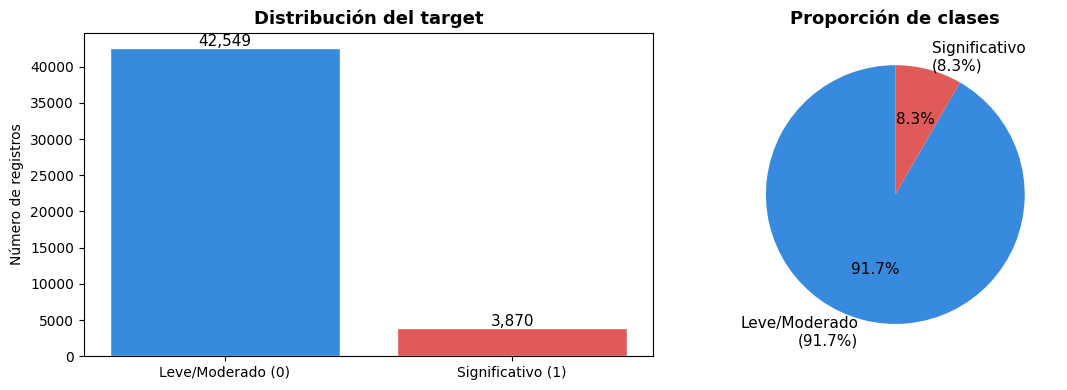


Dataset muy desbalanceado (ratio 11:1).
La métrica principal será F1-Score y ROC-AUC, NO accuracy.
Se aplicará class_weight="balanced" en el modelado.


In [21]:
#Visualización del balanceo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Barplot
colores = ['#378ADD', '#E05A5A']
axes[0].bar(['Leve/Moderado (0)', 'Significativo (1)'], counts.values, color=colores, edgecolor='white')
axes[0].set_title('Distribución del target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de registros')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=11)

#Pie chart
axes[1].pie(counts.values, labels=['Leve/Moderado\n(91.7%)', 'Significativo\n(8.3%)'],
            colors=colores, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nDataset muy desbalanceado (ratio 11:1).')
print('La métrica principal será F1-Score y ROC-AUC, NO accuracy.')
print('Se aplicará class_weight="balanced" en el modelado.')

### 2.2 Distribución geográfica del target

Visualizamos dónde se concentran los terremotos significativos para validar que la ubicación geográfica es una feature relevante.

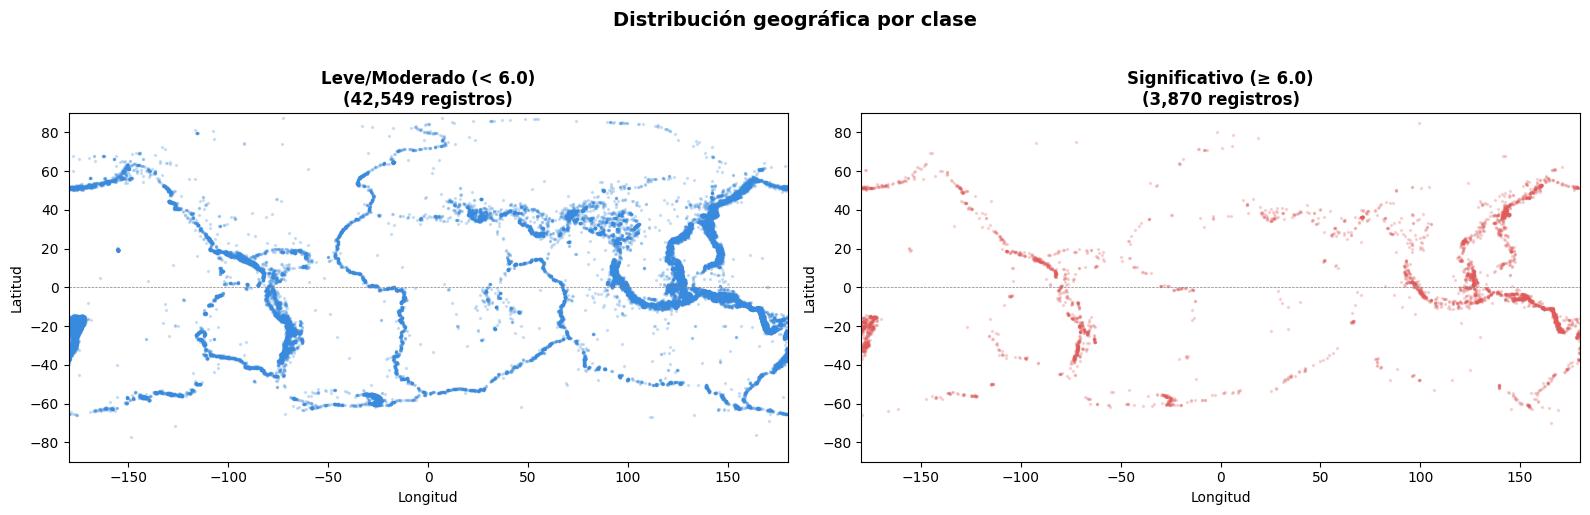

In [22]:
#Distribución geográfica por clase
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (clase, label, color) in zip(axes, [(0, 'Leve/Moderado (< 6.0)', '#378ADD'),
                                             (1, 'Significativo (≥ 6.0)', '#E05A5A')]):
    subset = df[df['es_severo'] == clase]
    ax.scatter(subset['longitude'], subset['latitude'],
               alpha=0.2, s=2, color=color)
    ax.set_title(f'{label}\n({len(subset):,} registros)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

plt.suptitle('Distribución geográfica por clase', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 3. Relación Features vs. Target

### 3.1 Profundidad vs. target

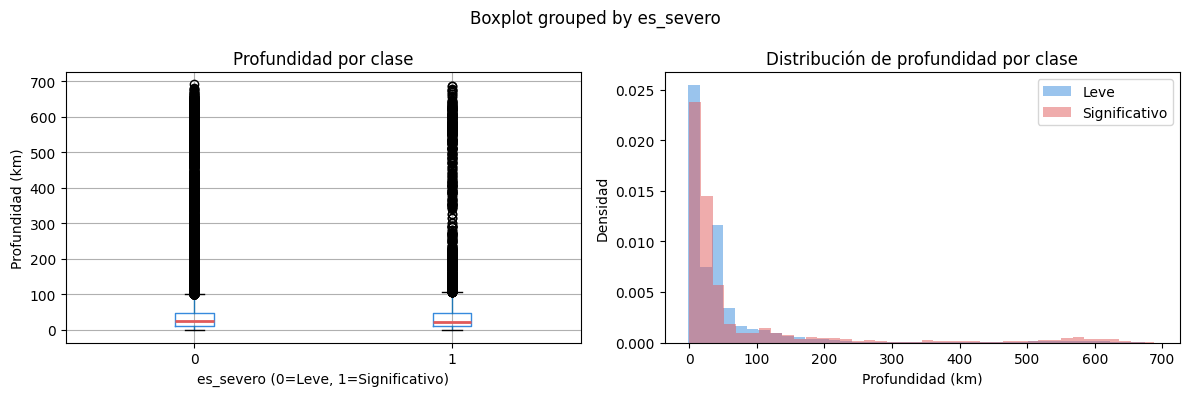

Profundidad media por clase:
             count   mean     std   min   25%   50%   75%    max
es_severo                                                       
0          42549.0  52.96   97.20 -1.77  10.0  23.7  46.1  691.6
1           3870.0  76.54  140.59  0.00  10.0  22.9  48.0  688.0


In [23]:
#Boxplot profundidad por clase
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Boxplot
df.boxplot(column='depth_km', by='es_severo', ax=axes[0],
           boxprops=dict(color='#378ADD'),
           medianprops=dict(color='#E05A5A', linewidth=2))
axes[0].set_title('Profundidad por clase')
axes[0].set_xlabel('es_severo (0=Leve, 1=Significativo)')
axes[0].set_ylabel('Profundidad (km)')
plt.sca(axes[0])
plt.title('Profundidad por clase')

#Distribución por clase
for clase, color, label in [(0, '#378ADD', 'Leve'), (1, '#E05A5A', 'Significativo')]:
    subset = df[df['es_severo'] == clase]['depth_km']
    axes[1].hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
axes[1].set_title('Distribución de profundidad por clase')
axes[1].set_xlabel('Profundidad (km)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.show()

#Estadísticas por clase
print('Profundidad media por clase:')
print(df.groupby('es_severo')['depth_km'].describe().round(2))

### 3.2 Latitud y Longitud vs. target

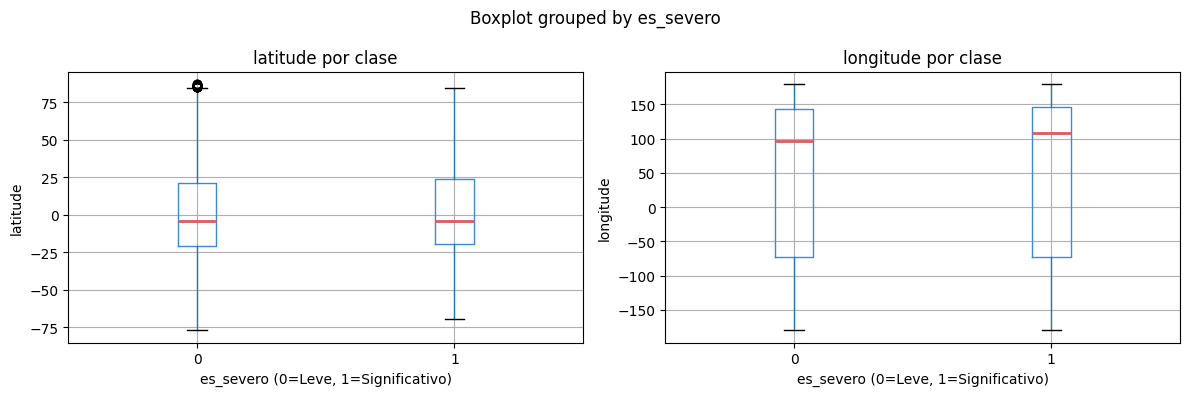


Estadísticas por clase:
           latitude  longitude  depth_km
es_severo                               
0             -0.78      38.58     52.96
1              0.62      43.88     76.54


In [24]:
#Boxplots latitud y longitud por clase
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['latitude', 'longitude']):
    df.boxplot(column=col, by='es_severo', ax=ax,
               boxprops=dict(color='#378ADD'),
               medianprops=dict(color='#E05A5A', linewidth=2))
    ax.set_xlabel('es_severo (0=Leve, 1=Significativo)')
    ax.set_ylabel(col)
    plt.sca(ax)
    plt.title(f'{col} por clase')

plt.tight_layout()
plt.show()

#Tasa de terremotos significativos por zona geográfica
print('\nEstadísticas por clase:')
print(df.groupby('es_severo')[['latitude', 'longitude', 'depth_km']].mean().round(2))

---

## 4. Detección y Tratamiento de Outliers

In [25]:
#Detección de outliers con método IQR
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lower) | (df[columna] > upper)]
    return outliers, lower, upper

numericas = ['latitude', 'longitude', 'depth_km']

print('Detección de outliers (método IQR):\n')
for col in numericas:
    outliers, lower, upper = detectar_outliers_iqr(df, col)
    pct = len(outliers) / len(df) * 100
    print(f'{col}: {len(outliers)} outliers ({pct:.1f}%) | rango válido: [{lower:.1f}, {upper:.1f}]')

Detección de outliers (método IQR):

latitude: 15 outliers (0.0%) | rango válido: [-84.6, 85.6]
longitude: 0 outliers (0.0%) | rango válido: [-396.0, 466.6]
depth_km: 5765 outliers (12.4%) | rango válido: [-44.3, 100.5]


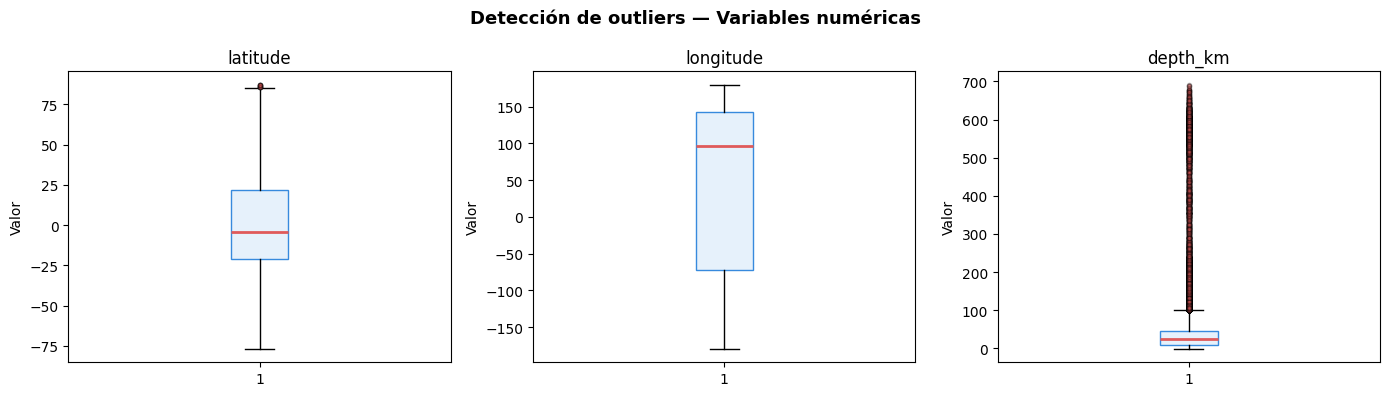


latitude y longitude: los outliers son coordenadas geográficas válidas — se mantienen.
depth_km: valores extremos posibles pero geofísicamente posibles — se mantienen.


In [26]:
#Visualización con boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, numericas):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#E6F1FB', color='#378ADD'),
               medianprops=dict(color='#E05A5A', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='#E05A5A', markersize=3, alpha=0.3))
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('Valor')

plt.suptitle('Detección de outliers — Variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nlatitude y longitude: los outliers son coordenadas geográficas válidas — se mantienen.')
print('depth_km: valores extremos posibles pero geofísicamente posibles — se mantienen.')

---

## 5. Correlaciones entre Features

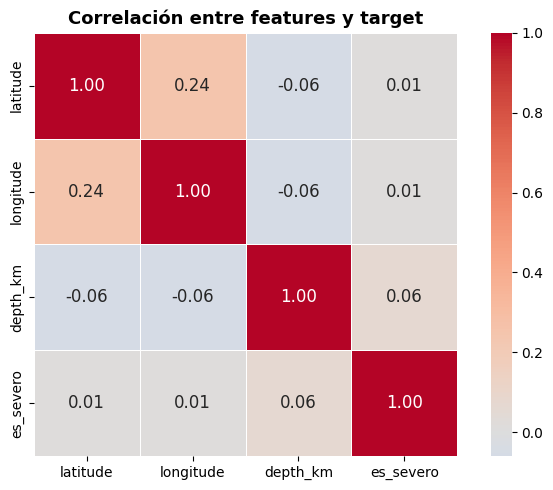


Correlación de cada feature con el target (es_severo):
depth_km     0.064
latitude     0.013
longitude    0.012
Name: es_severo, dtype: float64


In [27]:
#Heatmap de correlaciones
corr = df[['latitude', 'longitude', 'depth_km', 'es_severo']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 12})
ax.set_title('Correlación entre features y target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelación de cada feature con el target (es_severo):')
print(corr['es_severo'].drop('es_severo').sort_values(ascending=False).round(3))

---

## Parte 2 — Preprocesado & Feature Engineering

A partir del dataset limpio de la Parte 1, preparamos los datos para el modelado: división train/test, limpieza, feature engineering, encoding y escalado.

In [28]:
#Importamos las librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


In [29]:
# Cargamos el CSV original
df = pd.read_csv('src/data_sample/global_natural_disasters_2000_2025.csv')

# Replicamos exactamente lo que hizo la Parte 1

df['es_severo'] = (df['magnitude'] >= 6.0).astype(int)
df = df.drop(columns=['magnitude', 'country', 'deaths'])

print(f"Shape del dataset: {df.shape}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())
df.head()

Shape del dataset: (46419, 8)

Columnas disponibles:
['disaster_type', 'date', 'latitude', 'longitude', 'depth_km', 'location', 'source', 'es_severo']


,disaster_type,date,latitude,longitude,depth_km,location,source,es_severo
0,Earthquake,2000-01-01,36.874,69.947,54.3,"29 km SSE of Rust?q, Afghanistan",USGS,0
1,Earthquake,2000-01-01,-60.722,153.670,10.0,west of Macquarie Island,USGS,1
2,Earthquake,2000-01-01,23.112,143.644,33.0,"Volcano Islands, Japan region",USGS,0
3,Earthquake,2000-01-02,27.559,92.498,33.0,"33 km NNE of Bomdila, India",USGS,0
4,Earthquake,2000-01-02,-17.943,-178.476,582.3,"234 km E of Levuka, Fiji",USGS,0


## 1. División Train/Test


Antes de cualquier transformación dividimos el dataset en train y test.

- **Test size:** 20%
- **Stratify:** usamos `es_severo` para mantener la proporción de clases
  (91.7% / 8.3%) en ambos conjuntos

In [30]:
# Separamos features y target

X = df.drop(columns=['es_severo'])
y = df['es_severo']

# División estratificada

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} registros ({X_test.shape[0]/len(df)*100:.1f}%)")

# Verificamos que el stratify ha funcionado correctamente

print(f"\nProporción de clases en train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nProporción de clases en test:")
print(y_test.value_counts(normalize=True).round(3))

Train: 37135 registros (80.0%)
Test:  9284 registros (20.0%)

Proporción de clases en train:
es_severo
0    0.917
1    0.083
Name: proportion, dtype: float64

Proporción de clases en test:
es_severo
0    0.917
1    0.083
Name: proportion, dtype: float64


## 2. Limpieza de Datos

Revisamos tipos de dato, duplicados y valores missing **solo sobre train**
para no contaminar el test set.

In [31]:
# Tipos de dato

print("Tipos de dato:")
print(X_train.dtypes)

# Duplicados

duplicados = X_train.duplicated().sum()
print(f"\nDuplicados en train: {duplicados}")

# Missings

print("\nValores missing en train:")
missings = X_train.isnull().sum()
pct_missing = (X_train.isnull().sum() / len(X_train) * 100).round(2)
resumen_missing = pd.DataFrame({
    'Missing': missings,
    'Porcentaje': pct_missing
})
print(resumen_missing[resumen_missing['Missing'] > 0])

Tipos de dato:
disaster_type     object
date              object
latitude         float64
longitude        float64
depth_km         float64
location          object
source            object
dtype: object

Duplicados en train: 1

Valores missing en train:
Empty DataFrame
Columns: [Missing, Porcentaje]
Index: []


In [32]:
#Eliminamos el duplicado que tenemos

X_train = X_train.drop_duplicates()
y_train = y_train[X_train.index]

print(f"Shape train tras eliminar duplicados: {X_train.shape}")

Shape train tras eliminar duplicados: (37134, 7)


## 3. Feature Engineering

Creamos nuevas variables que pueden mejorar la capacidad predictiva del modelo:

- **Mes** y **año**: extraídos de la columna `date` — permiten capturar patrones temporales
- **Cinturón de Fuego**: variable binaria que indica si el terremoto ocurrió en el
  Cinturón de Fuego del Pacífico, zona con mayor actividad sísmica significativa
- **Prof_grupo**: categorización de la profundidad en grupos geofísicos estándar
  (superficial, intermedio, profundo)

In [33]:
def aplicar_feature_engineering(X):
    X = X.copy()
    
    # Extraemos mes y año de la fecha
    
    X['date'] = pd.to_datetime(X['date'])
    X['mes'] = X['date'].dt.month
    X['año'] = X['date'].dt.year
    
    # Cinturón de Fuego del Pacífico
    # Zona aproximada: longitud entre -180 y -60 (América) o entre 100 y 180 (Asia/Oceanía)
    # y latitud entre -60 y 70
    
    X['cinturon_fuego'] = (
        (
            ((X['longitude'] >= 100) & (X['longitude'] <= 180)) |
            ((X['longitude'] >= -180) & (X['longitude'] <= -60))
        ) &
        (X['latitude'] >= -60) & (X['latitude'] <= 70)
    ).astype(int)
    
    # Grupos de profundidad
    
    X['prof_grupo'] = pd.cut(
        X['depth_km'],
        bins=[-np.inf, 70, 300, np.inf],
        labels=['superficial', 'intermedio', 'profundo']
    )
    
    return X

# Aplicamos sobre train y test

X_train = aplicar_feature_engineering(X_train)
X_test  = aplicar_feature_engineering(X_test)

print("Nuevas features creadas:")
print(X_train[['mes', 'año', 'cinturon_fuego', 'prof_grupo']].head())
print(f"\nDistribución cinturon_fuego en train:")
print(X_train['cinturon_fuego'].value_counts())
print(f"\nDistribución prof_grupo en train:")
print(X_train['prof_grupo'].value_counts())

Nuevas features creadas:
       mes   año  cinturon_fuego   prof_grupo
27062   11  2014               0  superficial
1266    11  2000               1  superficial
22005   11  2011               1  superficial
27518    2  2015               1  superficial
40816   11  2022               1  superficial

Distribución cinturon_fuego en train:
cinturon_fuego
1    28793
0     8341
Name: count, dtype: int64

Distribución prof_grupo en train:
prof_grupo
superficial    30926
intermedio      4838
profundo        1370
Name: count, dtype: int64


In [34]:
from sklearn.preprocessing import OrdinalEncoder

# Eliminamos columnas que no vamos a necesitar

cols_eliminar = ['date', 'location', 'source', 'disaster_type']
X_train = X_train.drop(columns=cols_eliminar)
X_test  = X_test.drop(columns=cols_eliminar)

# Encoding ordinal de prof_grupo

ordinal_enc = OrdinalEncoder(categories=[['superficial', 'intermedio', 'profundo']])
X_train['prof_grupo'] = ordinal_enc.fit_transform(X_train[['prof_grupo']])
X_test['prof_grupo']  = ordinal_enc.transform(X_test[['prof_grupo']])

# Escalado de variables numéricas

cols_escalar = ['latitude', 'longitude', 'depth_km', 'mes', 'año']
scaler = StandardScaler()
X_train[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test[cols_escalar]  = scaler.transform(X_test[cols_escalar])

print("Columnas finales del dataset:")
print(X_train.columns.tolist())
print(f"\nShape train: {X_train.shape}")
print(f"Shape test:  {X_test.shape}")
print(f"\nPrimeras filas de X_train:")
X_train.head()

Columnas finales del dataset:
['latitude', 'longitude', 'depth_km', 'mes', 'año', 'cinturon_fuego', 'prof_grupo']

Shape train: (37134, 7)
Shape test:  (9284, 7)

Primeras filas de X_train:


,latitude,longitude,depth_km,mes,año,cinturon_fuego,prof_grupo
27062,0.271712,0.451745,-0.441241,1.287730,0.176815,0,0.0
1266,-0.192734,0.540315,-0.250326,1.287730,-1.749461,1,0.0
22005,-0.742767,-1.743239,-0.240485,1.287730,-0.235958,1,0.0
27518,-0.508023,-1.772306,-0.195217,-1.283315,0.314406,1,0.0
40816,-0.301739,0.982726,-0.441241,1.287730,1.277544,1,0.0


## 5. Tabla Resumen de Variables

Resumen de todas las variables del dataset final con su tipo, origen y descripción.

In [35]:
tabla_variables = pd.DataFrame({
    'Variable': ['latitude', 'longitude', 'depth_km', 'mes', 'año', 
                 'cinturon_fuego', 'prof_grupo', 'es_severo'],
    'Tipo': ['Numérica continua', 'Numérica continua', 'Numérica continua', 
             'Numérica discreta', 'Numérica discreta',
             'Binaria', 'Categórica ordinal', 'Binaria (target)'],
    'Origen': ['Original', 'Original', 'Original', 'Engineered', 'Engineered',
               'Engineered', 'Engineered', 'Engineered (Parte 1)'],
    'Descripción': [
        'Latitud del epicentro',
        'Longitud del epicentro',
        'Profundidad del terremoto en km',
        'Mes del terremoto (1-12)',
        'Año del terremoto (2000-2025)',
        '1 si ocurrió en el Cinturón de Fuego del Pacífico',
        'Profundidad categorizada: superficial / intermedio / profundo',
        '1 = terremoto significativo (magnitud ≥ 6.0)'
    ]
})

print(tabla_variables.to_string(index=False))

      Variable               Tipo               Origen                                                   Descripción
      latitude  Numérica continua             Original                                         Latitud del epicentro
     longitude  Numérica continua             Original                                        Longitud del epicentro
      depth_km  Numérica continua             Original                               Profundidad del terremoto en km
           mes  Numérica discreta           Engineered                                      Mes del terremoto (1-12)
           año  Numérica discreta           Engineered                                 Año del terremoto (2000-2025)
cinturon_fuego            Binaria           Engineered             1 si ocurrió en el Cinturón de Fuego del Pacífico
    prof_grupo Categórica ordinal           Engineered Profundidad categorizada: superficial / intermedio / profundo
     es_severo   Binaria (target) Engineered (Parte 1)          

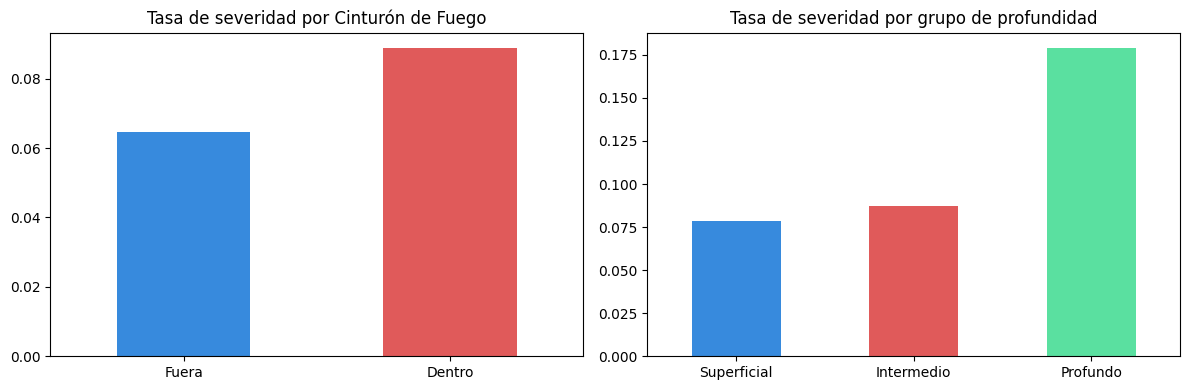

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

X_train_viz = X_train.copy()
X_train_viz['es_severo'] = y_train.values

X_train_viz.groupby('cinturon_fuego')['es_severo'].mean().plot(
    kind='bar', ax=axes[0], color=['#378ADD', '#E05A5A']
)
axes[0].set_title('Tasa de severidad por Cinturón de Fuego')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Fuera', 'Dentro'], rotation=0)

X_train_viz.groupby('prof_grupo')['es_severo'].mean().plot(
    kind='bar', ax=axes[1], color=['#378ADD', '#E05A5A', '#5AE0A0']
)
axes[1].set_title('Tasa de severidad por grupo de profundidad')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Superficial', 'Intermedio', 'Profundo'], rotation=0)

plt.tight_layout()
plt.show()

### Validación de features engineeradas

- De media, el **9% de los terremotos dentro del Cinturón de Fuego** son significativos,
  frente al 6.5% fuera de él.
- Los terremotos **profundos** (> 300km) tienen una tasa media de severidad del 18%,
  más del doble que los superficiales (8%). Esto justifica la creación de `prof_grupo`.
- Ambas features engineeradas muestran **poder predictivo real** y se incluyen
  en el modelo.

---

## Parte 3 — Modelado & Evaluación

Comparativa de modelos, optimización de hiperparámetros, evaluación final contra test y guardado del modelo.

## 1. Selección de Features

Entrenamos un Random Forest para ver qué variables aportan más a la predicción.

In [37]:
from sklearn.ensemble import RandomForestClassifier

# Modelo rápido solo para extraer importancia de features
# class_weight='balanced' compensa el desbalanceo (91.7% / 8.3%)
rf_temp = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_temp.fit(X_train, y_train)

# Importancia de cada variable, ordenada de mayor a menor
importancias = pd.Series(rf_temp.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importancias)

longitude         0.258971
latitude          0.257514
depth_km          0.225822
año               0.134697
mes               0.103459
prof_grupo        0.012271
cinturon_fuego    0.007267
dtype: float64


Mantenemos las 7 features: `latitude`, `longitude` y `depth_km` son las más determinantes; las derivadas (`prof_grupo`, `cinturon_fuego`) aportan poco pero no restan.

## 2. Baseline y Comparativa de Modelos

Empezamos con un baseline simple (DummyClassifier) como referencia mínima, y después comparamos varios modelos con validación cruzada.

In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

# Baseline: predice siempre la clase mayoritaria

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

# Evaluamos con F1 (accuracy no sirve por el desbalanceo)

f1_dummy = cross_val_score(dummy, X_train, y_train, cv=5, scoring='f1').mean()
print(f"F1 del baseline (DummyClassifier): {f1_dummy:.4f}")

F1 del baseline (DummyClassifier): 0.0000


El baseline obtiene F1 = 0 al predecir siempre la clase mayoritaria (nunca detecta terremotos severos).

Comparamos 4 modelos con validación cruzada (5-fold), usando F1 como métrica.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Diccionario con los modelos a comparar
# class_weight='balanced' en los que lo soportan, para compensar el desbalanceo

modelos = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier()
}

# Evaluamos cada modelo con CV y guardamos el F1 medio

resultados = {}
for nombre, modelo in modelos.items():
    f1_scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1')
    resultados[nombre] = f1_scores.mean()
    print(f"{nombre}: F1 = {f1_scores.mean():.4f}")

Logistic Regression: F1 = 0.1654
Decision Tree: F1 = 0.1968
Random Forest: F1 = 0.0469
KNN: F1 = 0.0357


Decision Tree obtiene el mejor F1 (0.1968), seguido de Logistic Regression (0.1654). Random Forest y KNN rinden peor: RF por el efecto del promediado de árboles sobre clases desbalanceadas, y KNN por no soportar `class_weight`.

## 3. Optimización de Hiperparámetros

Ajustamos Decision Tree y Logistic Regression con GridSearchCV, ya que fueron los mejores en la comparativa.

In [40]:
from sklearn.model_selection import GridSearchCV

# Rango de hiperparámetros a probar

param_grid_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid_tree,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_tree.fit(X_train, y_train)

print(f"Mejores parámetros (Decision Tree): {grid_tree.best_params_}")
print(f"Mejor F1 (Decision Tree): {grid_tree.best_score_:.4f}")

Mejores parámetros (Decision Tree): {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Mejor F1 (Decision Tree): 0.2397


In [41]:
# Rango de hiperparámetros a probar

param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_log = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid_log,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_log.fit(X_train, y_train)

print(f"Mejores parámetros (Logistic Regression): {grid_log.best_params_}")
print(f"Mejor F1 (Logistic Regression): {grid_log.best_score_:.4f}")

Mejores parámetros (Logistic Regression): {'C': 0.01, 'solver': 'liblinear'}
Mejor F1 (Logistic Regression): 0.1655


El Decision Tree optimizado mejora el F1 de 0.1968 a 0.2397 con `max_depth=5`. Logistic Regression apenas mejora, se mantiene cerca de su rendimiento base. Elegimos el Decision Tree como modelo final.

## 4. Evaluación Final contra Test

Evaluamos el modelo final (Decision Tree optimizado) contra el conjunto de test.

F1 en test: 0.2543
ROC-AUC en test: 0.6808

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.76      0.84      8510
           1       0.17      0.53      0.25       774

    accuracy                           0.74      9284
   macro avg       0.56      0.65      0.55      9284
weighted avg       0.88      0.74      0.79      9284



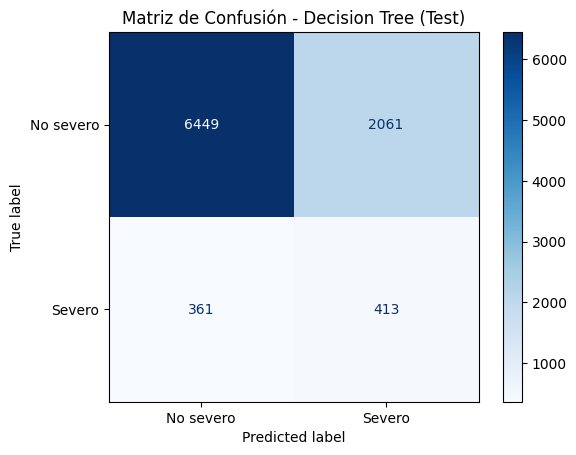

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, f1_score, classification_report

# Modelo final ya entrenado por GridSearchCV con los mejores parámetros

modelo_final = grid_tree.best_estimator_

# Predicciones sobre test

y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

# Métricas

f1_test = f1_score(y_test, y_pred)
roc_auc_test = roc_auc_score(y_test, y_proba)

print(f"F1 en test: {f1_test:.4f}")
print(f"ROC-AUC en test: {roc_auc_test:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No severo', 'Severo'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Decision Tree (Test)')
plt.show()

El modelo detecta el 53% de los terremotos severos (recall), a costa de una precisión baja (17%) por las falsas alarmas. Dado el contexto de alerta temprana, priorizar el recall sobre la precisión es una decisión razonable: es preferible una falsa alarma que no detectar un terremoto severo.

## Ajuste del Umbral de Decisión

Probamos distintos umbrales de probabilidad para ver si mejoramos el F1 respecto al umbral por defecto (0.5).

In [43]:
from sklearn.metrics import f1_score

# Probamos distintos umbrales sobre las probabilidades ya calculadas
umbrales = np.arange(0.1, 0.85, 0.05)
resultados_umbral = []

for u in umbrales:
    y_pred_u = (y_proba >= u).astype(int)
    f1_u = f1_score(y_test, y_pred_u)
    resultados_umbral.append(f1_u)
    print(f"Umbral {u:.2f}: F1 = {f1_u:.4f}")

# Umbral que maximiza F1
mejor_umbral = umbrales[np.argmax(resultados_umbral)]
print(f"\nMejor umbral: {mejor_umbral:.2f} (F1 = {max(resultados_umbral):.4f})")

Umbral 0.10: F1 = 0.1538
Umbral 0.15: F1 = 0.1538
Umbral 0.20: F1 = 0.1538
Umbral 0.25: F1 = 0.1588
Umbral 0.30: F1 = 0.1844
Umbral 0.35: F1 = 0.1844
Umbral 0.40: F1 = 0.1923
Umbral 0.45: F1 = 0.2289
Umbral 0.50: F1 = 0.2543
Umbral 0.55: F1 = 0.2572
Umbral 0.60: F1 = 0.2654
Umbral 0.65: F1 = 0.2677
Umbral 0.70: F1 = 0.2677
Umbral 0.75: F1 = 0.1186
Umbral 0.80: F1 = 0.1186

Mejor umbral: 0.65 (F1 = 0.2677)


El umbral óptimo es 0.65 (F1 = 0.2677), ligera mejora sobre el umbral por defecto (0.5 → F1 = 0.2543). Recalculamos las métricas finales con este umbral.

F1 en test (umbral 0.65): 0.2677
ROC-AUC en test: 0.6808

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      8510
           1       0.21      0.37      0.27       774

    accuracy                           0.83      9284
   macro avg       0.57      0.62      0.59      9284
weighted avg       0.88      0.83      0.85      9284



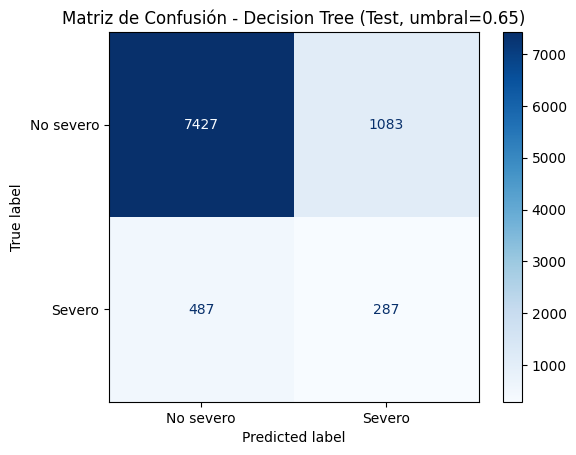

In [44]:
# Aplicamos el umbral óptimo encontrado
umbral_optimo = 0.65
y_pred_ajustado = (y_proba >= umbral_optimo).astype(int)

f1_final = f1_score(y_test, y_pred_ajustado)
roc_auc_final = roc_auc_score(y_test, y_proba)  # ROC-AUC no depende del umbral

print(f"F1 en test (umbral {umbral_optimo}): {f1_final:.4f}")
print(f"ROC-AUC en test: {roc_auc_final:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ajustado))

cm_ajustada = confusion_matrix(y_test, y_pred_ajustado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ajustada, display_labels=['No severo', 'Severo'])
disp.plot(cmap='Blues')
plt.title(f'Matriz de Confusión - Decision Tree (Test, umbral={umbral_optimo})')
plt.show()

## Decisión sobre el Umbral

Aunque el umbral 0.65 da un F1 ligeramente superior (0.2677 vs 0.2543), reduce el recall de la clase "Severo" de 53% a 37% — es decir, detecta menos terremotos severos reales.

En un sistema de alerta temprana, es preferible asumir más falsas alarmas que dejar pasar terremotos severos sin avisar. Por eso mantenemos el umbral por defecto (0.5), que prioriza el recall sobre la precisión.

## Exploración con SMOTE

Probamos si generar ejemplos sintéticos de la clase minoritaria con SMOTE mejora el recall de los terremotos severos.

In [45]:
from imblearn.over_sampling import SMOTE

# Generamos ejemplos sintéticos de la clase minoritaria solo en train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribución original en train: {y_train.value_counts().to_dict()}")
print(f"Distribución tras SMOTE: {y_train_smote.value_counts().to_dict()}")

# Reentrenamos el Decision Tree con los mismos hiperparámetros óptimos, pero con datos balanceados
modelo_smote = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=2, random_state=42)
modelo_smote.fit(X_train_smote, y_train_smote)

# Evaluamos contra el mismo test de siempre (sin tocar)
y_pred_smote = modelo_smote.predict(X_test)
f1_smote = f1_score(y_test, y_pred_smote)

print(f"\nF1 en test (con SMOTE): {f1_smote:.4f}")
print("\nClassification Report (con SMOTE):")
print(classification_report(y_test, y_pred_smote))

Distribución original en train: {0: 34038, 1: 3096}
Distribución tras SMOTE: {0: 34038, 1: 34038}

F1 en test (con SMOTE): 0.2276

Classification Report (con SMOTE):
              precision    recall  f1-score   support

           0       0.95      0.67      0.79      8510
           1       0.14      0.59      0.23       774

    accuracy                           0.67      9284
   macro avg       0.54      0.63      0.51      9284
weighted avg       0.88      0.67      0.74      9284



SMOTE mejora el recall de la clase Severo (59% vs 53%), a costa de un F1 global algo menor (0.2276 vs 0.2543) por el aumento de falsas alarmas sobre la clase mayoritaria. 

Dado que el objetivo es un sistema de alerta temprana, donde es preferible una falsa alarma a no detectar un terremoto severo, nos quedamos con el modelo entrenado con SMOTE como modelo final.

## 5. Guardado del Modelo

In [47]:
import joblib

# Guardamos el modelo con SMOTE, mejor recall para detección de terremotos severos
joblib.dump(modelo_smote, 'src/models/decision_tree_sismicidad.joblib')
print("Modelo guardado en src/models/decision_tree_sismicidad.joblib")

Modelo guardado en src/models/decision_tree_sismicidad.joblib
